In [1]:
#import library
import pandas as pd #untuk mengolah data
import numpy as np #untuk mengolah data numerik
import matplotlib.pyplot as plt #untuk visualisasi data
import seaborn as sns #untuk visualisasi data

from sklearn.model_selection import train_test_split #untuk membagi data menjadi data latih dan data uji
from sklearn.preprocessing import StandardScaler #untuk melakukan standarisasi data (normalisasi data)
from sklearn.svm import SVC #untuk membuat model Support Vector Machine (SVM)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #untuk mengevaluasi model dengan menghitung akurasi, membuat laporan klasifikasi, dan membuat matriks kebingungan (confusion matrix)

In [2]:
#load dataset 
data = pd.read_csv('dataset_ispa_svm.csv') #memuat dataset

data.head() #menampilkan 5 pertama secara default

,JK,Usia,Demam,Batuk,Sesak_Nafas,Sakit_Tenggorokan,Hidung_Tersumbat,Kategori_ISPA
0,LK,53,1,1,1,0,0,ISPA Berat
1,PR,24,1,1,0,1,0,ISPA Berat
2,LK,26,1,0,1,1,0,ISPA Berat
3,LK,60,0,1,0,1,0,ISPA Ringan
4,LK,41,1,0,1,0,1,ISPA Berat


In [3]:
#cek informasi dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   JK                 120 non-null    object
 1   Usia               120 non-null    int64 
 2   Demam              120 non-null    int64 
 3   Batuk              120 non-null    int64 
 4   Sesak_Nafas        120 non-null    int64 
 5   Sakit_Tenggorokan  120 non-null    int64 
 6   Hidung_Tersumbat   120 non-null    int64 
 7   Kategori_ISPA      120 non-null    object
dtypes: int64(6), object(2)
memory usage: 7.6+ KB


In [4]:
data.describe() #menampilkan statistik deskriptif dari dataset

,Usia,Demam,Batuk,Sesak_Nafas,Sakit_Tenggorokan,Hidung_Tersumbat
count,120.000000,120.000000,120.000000,120.000000,120.00000,120.000000
mean,38.483333,0.633333,0.675000,0.358333,0.45000,0.483333
std,23.471772,0.483915,0.470339,0.481521,0.49958,0.501817
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,18.500000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,37.500000,1.000000,1.000000,0.000000,0.00000,0.000000
75%,59.000000,1.000000,1.000000,1.000000,1.00000,1.000000
max,79.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [5]:
#label encoding
data['JK'] = data['JK'].map({'LK':1, 'PR':0})
data['Kategori_ISPA'] = data['Kategori_ISPA'].map({'ISPA Berat':2, 'ISPA Ringan':1})

In [6]:
data.head() #menampilkan 5 pertama secara default

,JK,Usia,Demam,Batuk,Sesak_Nafas,Sakit_Tenggorokan,Hidung_Tersumbat,Kategori_ISPA
0,1,53,1,1,1,0,0,2
1,0,24,1,1,0,1,0,2
2,1,26,1,0,1,1,0,2
3,1,60,0,1,0,1,0,1
4,1,41,1,0,1,0,1,2


In [7]:
#pisahkan fitur dan target

x = data.drop('Kategori_ISPA', axis=1)
y = data['Kategori_ISPA']

In [8]:
# split data training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [9]:
#standarisasi data (normalisasi data) agar skala sama
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
#training model SVM
model = SVC(kernel='rbf', C=1)

model.fit(X_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [11]:
#model memprediksi data testing
y_pred = model.predict(X_test)

In [12]:
#evaluasi model 
print("Accuracy :", accuracy_score(y_test, y_pred)) #menentukan seberapa benar model

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred)) #deatilnya benar atau salah

print("\nClassification Report")
print(classification_report(y_test, y_pred)) #precision, recall, f-1score

Accuracy : 0.9166666666666666

Confusion Matrix
[[ 7  0]
 [ 2 15]]

Classification Report
              precision    recall  f1-score   support

           1       0.78      1.00      0.88         7
           2       1.00      0.88      0.94        17

    accuracy                           0.92        24
   macro avg       0.89      0.94      0.91        24
weighted avg       0.94      0.92      0.92        24



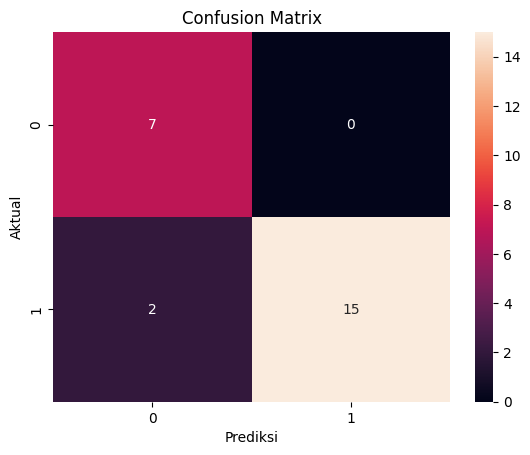

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# TP 7 TN 15 FN 0 FP 2

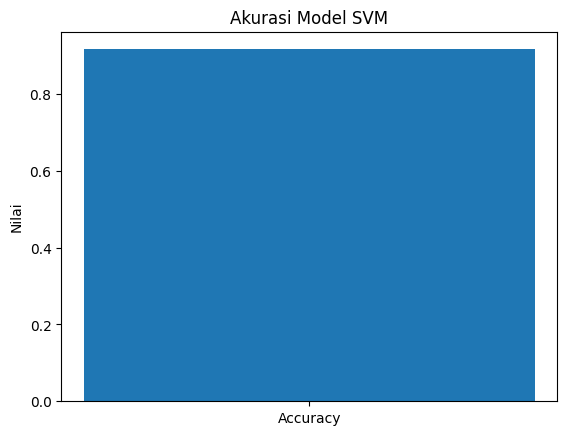

In [14]:
acc = accuracy_score(y_test, y_pred)

plt.figure()
plt.bar(['Accuracy'], [acc])
plt.title("Akurasi Model SVM")
plt.ylabel("Nilai")
plt.show()

#akurasi hampir mendekati 1